--- PCA Dimension Compression Summary ---
Original Feature Dimension : 512 features
Compressed Dimension (88%) : 424 features
Total Compression Squeeze  : 17.2% reduction


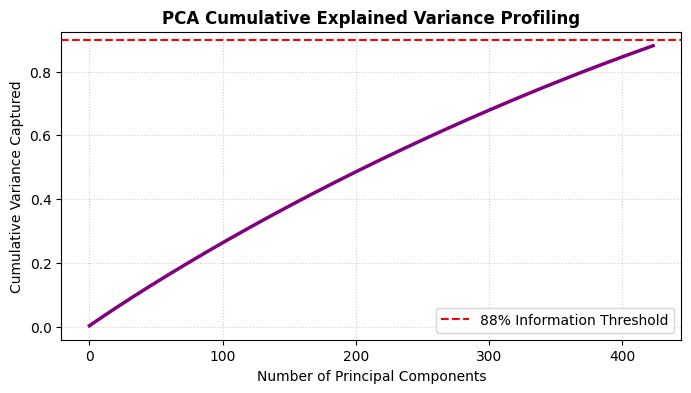

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
fake_embeddings = np.random.randn(10000, 512)

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(fake_embeddings)

pca = PCA(n_components=0.88, random_state=42)
compressed_embeddings = pca.fit_transform(embeddings_scaled)

print("--- PCA Dimension Compression Summary ---")
print(f"Original Feature Dimension : {fake_embeddings.shape[1]} features")
print(f"Compressed Dimension (88%) : {compressed_embeddings.shape[1]} features")
print(f"Total Compression Squeeze  : {100 - (compressed_embeddings.shape[1] / fake_embeddings.shape[1] * 100):.1f}% reduction")

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=2.5, color='purple')
plt.title("PCA Cumulative Explained Variance Profiling", fontsize=12, fontweight='bold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Captured")
plt.axhline(y=0.90, color='r', linestyle='--', label='88% Information Threshold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()